# Mô phỏng chỉ số VN30

Notebook này thực hiện việc lọc các mã cổ phiếu thuộc rổ VN30 và tính toán biến động luỹ kế dựa trên phương pháp trọng số đều (Equal-Weight) để mô phỏng biểu đồ của VN30. Do không có sẵn dữ liệu khối lượng lưu hành (shares outstanding) để tính vốn hoá thị trường chính xác, phương pháp Equal-Weight (trung bình đều) cung cấp một mô phỏng tương đối và trực quan đánh giá nhóm VN30.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')

In [30]:
# 1. Đọc danh sách mã VN30
with open('../market_lists/vn100.txt', 'r') as f:
    vn100_tickers = [line.strip() for line in f.readlines() if line.strip()]

print(f"Số lượng mã VN100 tải được: {len(vn100_tickers)}")
print("Danh sách:", vn100_tickers)

Số lượng mã VN100 tải được: 100
Danh sách: ['ACB', 'ANV', 'BCM', 'BID', 'BMP', 'BSI', 'BVH', 'BWE', 'CII', 'CMG', 'CTD', 'CTG', 'CTR', 'CTS', 'DBC', 'DCM', 'DGC', 'DGW', 'DIG', 'DPM', 'DSE', 'DXG', 'DXS', 'EIB', 'EVF', 'FPT', 'FRT', 'FTS', 'GAS', 'GEE', 'GEX', 'GMD', 'GVR', 'HAG', 'HCM', 'HDB', 'HDC', 'HDG', 'HHV', 'HPG', 'HSG', 'HT1', 'IMP', 'KBC', 'KDC', 'KDH', 'KOS', 'LPB', 'MBB', 'MSB', 'MSN', 'MWG', 'NAB', 'NKG', 'NLG', 'NT2', 'OCB', 'PAN', 'PC1', 'PDR', 'PHR', 'PLX', 'PNJ', 'POW', 'PPC', 'PTB', 'PVD', 'PVT', 'REE', 'SAB', 'SBT', 'SCS', 'SHB', 'SIP', 'SJS', 'SSB', 'SSI', 'STB', 'SZC', 'TCB', 'TCH', 'TLG', 'TPB', 'VCB', 'VCG', 'VCI', 'VGC', 'VHC', 'VHM', 'VIB', 'VIC', 'VIX', 'VJC', 'VND', 'VNM', 'VPB', 'VPI', 'VRE', 'VSC', 'VTP']


In [31]:
# 2. Tải dữ liệu lịch sử và lọc VN30
data_path = '../data/processed/assets/data_info_vn/history/vn_gold_recommended.csv'
cols = ['Date', 'code', 'intraday_return', 'adjust']
# df = pd.read_csv(data_path, usecols=cols)
df = pd.read_csv(data_path)
print(df.columns)


# Chuyển Date sang chuẩn datetime
df['Date'] = pd.to_datetime(df['Date'])

# Lọc các mã trong rổ VN100
vn100_df = df[df['code'].isin(vn100_tickers)].copy()
vn100_df.dropna(subset=['intraday_return'], inplace=True)
print("Dữ liệu VN100 tải về thành công, kích thước:", vn100_df.shape)
print(vn100_df.head())



Index(['Date', 'code', 'sector', 'exchange', 'open', 'high', 'low', 'close',
       'adjust', 'ma_5', 'ma_20', 'volume_match', 'volume_ma_5',
       'volume_ma_20', 'volume_ratio_20', 'intraday_return', 'gap_open',
       'close_position', 'upper_shadow', 'lower_shadow', 'momentum_5',
       'momentum_20', 'volatility_20', 'ma_200_gap', 'rolling_max_20_gap',
       'bb_width', 'vwap_gap', 'obv_change', 'macd_hist',
       'effort_result_ratio', 'buying_pressure', 'selling_pressure',
       'wyckoff_phase_60d', 'rsi_14', 'day_of_week', 'sector_momentum_rank',
       'is_top_2_sector', 'vwap_gap_20', 'above_ma_200', 'alpha_sector',
       'target_next_price', 'target_next_growth_pct', 'target_next_return',
       'target_next_3d_return', 'target_next_5d_return'],
      dtype='str')
Dữ liệu VN100 tải về thành công, kích thước: (277096, 45)
        Date code     sector exchange  open  high   low  close       adjust  \
0 2012-03-20  ACB  Ngân hàng     HOSE  3460  3530  3420   3480  4194.301

In [32]:
# 3. Tính toán Index Mô phỏng (Equal-Weight)
# Tính trung bình tỷ suất sinh lời của rổ VN30 trong mỗi ngày
vn100_daily = vn100_df.groupby('Date').agg(
    daily_return=('intraday_return', 'mean'),
    stock_count=('code', 'count')
).reset_index()

# Tính lợi nhuận luỹ kế (Cumulative Return)
# Giả định điểm bắt đầu là giá trị 1000
vn100_daily['cum_return'] = (1 + vn100_daily['daily_return']).cumprod()
vn100_daily['simulated_index'] = 1000 * vn100_daily['cum_return']

vn100_daily.set_index('Date', inplace=True)
display(vn100_daily.head())

,daily_return,stock_count,cum_return,simulated_index
Date,,,,
2012-03-19,0.023810,1,1.023810,1023.809524
2012-03-20,0.011309,54,1.035388,1035.388176
2012-03-21,0.007119,52,1.042759,1042.758919
2012-03-22,0.009204,53,1.052356,1052.356130
2012-03-23,0.003675,53,1.056224,1056.223754


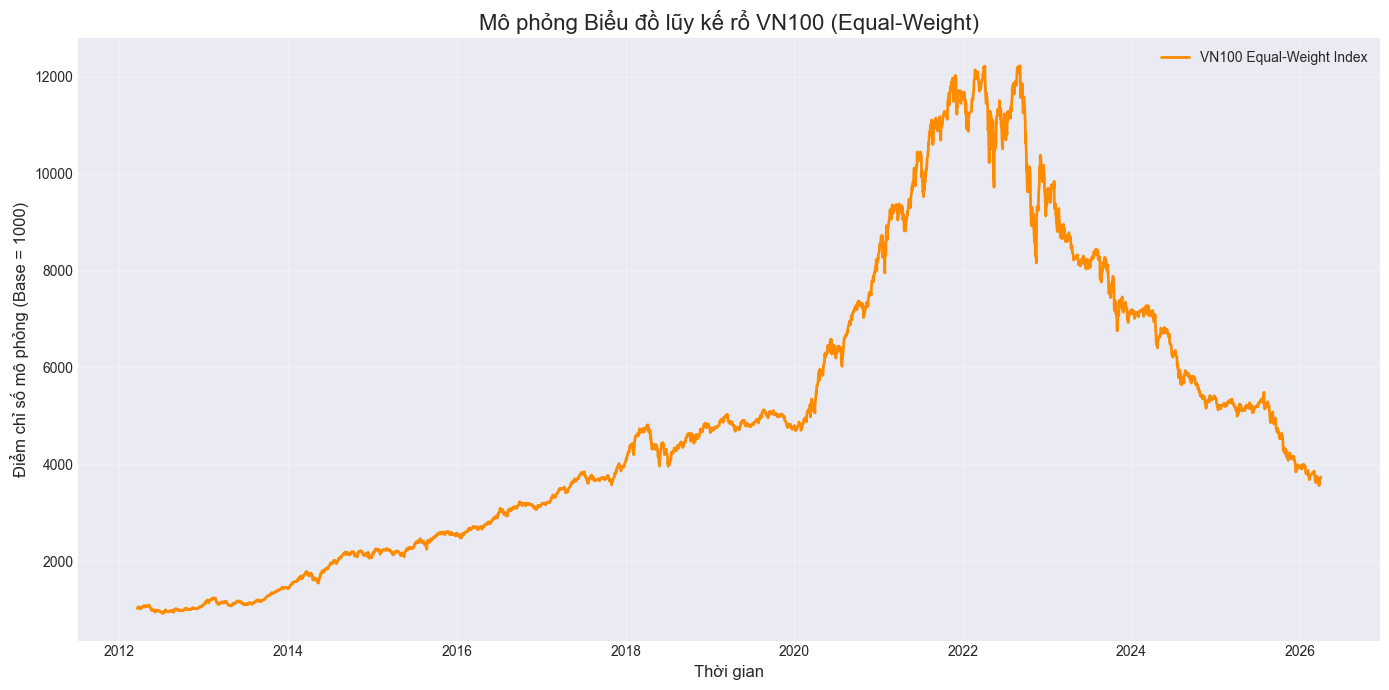

In [33]:
# 4. Vẽ biểu đồ
plt.figure(figsize=(14, 7))
plt.plot(vn100_daily.index, vn100_daily['simulated_index'], label='VN100 Equal-Weight Index', color='darkorange', linewidth=2)
plt.title('Mô phỏng Biểu đồ lũy kế rổ VN100 (Equal-Weight)', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Điểm chỉ số mô phỏng (Base = 1000)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Chuẩn hóa để tính growth cho từng mã

Ở đây **không dùng z-score hoặc min-max để tính growth**.  
Growth được tính trực tiếp từ giá gốc, ưu tiên dùng cột `adjust` nếu có:

- **Total growth** từ ngày đầu đến ngày cuối:
  \[
  \text{growth} = \frac{P_n}{P_0} - 1
  \]

- **Chuỗi tăng trưởng chuẩn hóa để so sánh nhiều mã**:
  \[
  \text{rebased\_100}_t = 100 \times \frac{P_t}{P_0}
  \]

Ngoài ra, notebook cũng tính thêm:

- `simple_return`: \( P_t / P_{t-1} - 1 \)
- `log_return`: \( \ln(P_t / P_{t-1}) \)

Cách này phù hợp hơn cho dữ liệu chứng khoán khi phân tích và khi làm feature cho mô hình.


In [34]:

# 5.1 Chuẩn bị dữ liệu giá để tính growth theo từng mã

price_col = 'adjust' if 'adjust' in vn100_df.columns else 'Close'
required_cols = ['Date', 'code', price_col]

growth_df = (
    vn100_df[required_cols]
    .dropna(subset=[price_col])
    .sort_values(['code', 'Date'])
    .copy()
)

# Giá đầu kỳ và cuối kỳ của từng mã
growth_summary = (
    growth_df.groupby('code')
    .agg(
        start_date=('Date', 'first'),
        end_date=('Date', 'last'),
        start_price=(price_col, 'first'),
        end_price=(price_col, 'last'),
        observations=(price_col, 'size')
    )
    .reset_index()
)

growth_summary['total_growth'] = growth_summary['end_price'] / growth_summary['start_price'] - 1
growth_summary['total_growth_pct'] = growth_summary['total_growth'] * 100

# Sắp xếp giảm dần theo growth
growth_summary = growth_summary.sort_values('total_growth', ascending=False).reset_index(drop=True)

print(f"Cột giá đang dùng để tính growth: {price_col}")
display(growth_summary.head(15))


Cột giá đang dùng để tính growth: adjust


,code,start_date,end_date,start_price,end_price,observations,total_growth,total_growth_pct
0,NT2,2012-03-19,2026-03-31,430.000000,27600.0,3306,63.186047,6318.604651
1,PTB,2012-03-20,2026-03-31,1220.000000,49650.0,3495,39.696721,3969.672131
2,GEX,2015-10-26,2026-03-31,1010.000000,37000.0,2567,35.633663,3563.366337
3,HPG,2012-03-26,2026-03-31,1273.106445,26900.0,3494,20.129419,2012.941938
4,BMP,2012-03-20,2026-03-31,6560.000000,129100.0,3500,18.679878,1867.987805
5,MWG,2014-07-14,2026-03-31,4300.000000,81800.0,2922,18.023256,1802.325581
6,PNJ,2012-03-20,2026-03-31,6160.000000,108000.0,3498,16.532468,1653.246753
7,VIC,2012-03-20,2026-03-31,8424.108398,135000.0,3498,15.025435,1502.543481
8,TLG,2012-03-20,2026-03-31,3039.690186,48500.0,3497,14.955573,1495.557344
9,HDG,2012-03-20,2026-03-31,1975.533936,29600.0,3498,13.983291,1398.329108


In [35]:

# 5.2 Tạo chuỗi chuẩn hóa theo từng mã: rebased_100, simple_return, log_return

growth_df['base_price'] = growth_df.groupby('code')[price_col].transform('first')
growth_df['prev_price'] = growth_df.groupby('code')[price_col].shift(1)

# Chuẩn hóa về mốc 100 để so sánh nhiều mã trên cùng một biểu đồ
growth_df['rebased_100'] = 100 * growth_df[price_col] / growth_df['base_price']

# Tỷ suất sinh lời theo ngày
growth_df['simple_return'] = growth_df[price_col] / growth_df['prev_price'] - 1
growth_df['log_return'] = np.log(growth_df[price_col] / growth_df['prev_price'])

display(growth_df.head(10))


,Date,code,adjust,base_price,prev_price,rebased_100,simple_return,log_return
0,2012-03-20,ACB,4194.301758,4194.301758,NaN,100.000000,NaN,NaN
1,2012-03-21,ACB,4210.622559,4194.301758,4194.301758,100.389118,0.003891,0.003884
2,2012-03-22,ACB,4210.622559,4194.301758,4210.622559,100.389118,0.000000,0.000000
3,2012-03-23,ACB,4177.981934,4194.301758,4210.622559,99.610905,-0.007752,-0.007782
4,2012-03-26,ACB,4210.622559,4194.301758,4177.981934,100.389118,0.007813,0.007782
5,2012-03-27,ACB,4080.060303,4194.301758,4210.622559,97.276270,-0.031008,-0.031499
6,2012-03-28,ACB,4096.380371,4194.301758,4080.060303,97.665371,0.004000,0.003992
7,2012-03-29,ACB,4014.779297,4194.301758,4096.380371,95.719849,-0.019920,-0.020121
8,2012-03-30,ACB,4014.779297,4194.301758,4014.779297,95.719849,0.000000,0.000000
9,2012-04-03,ACB,4080.060303,4194.301758,4014.779297,97.276270,0.016260,0.016129


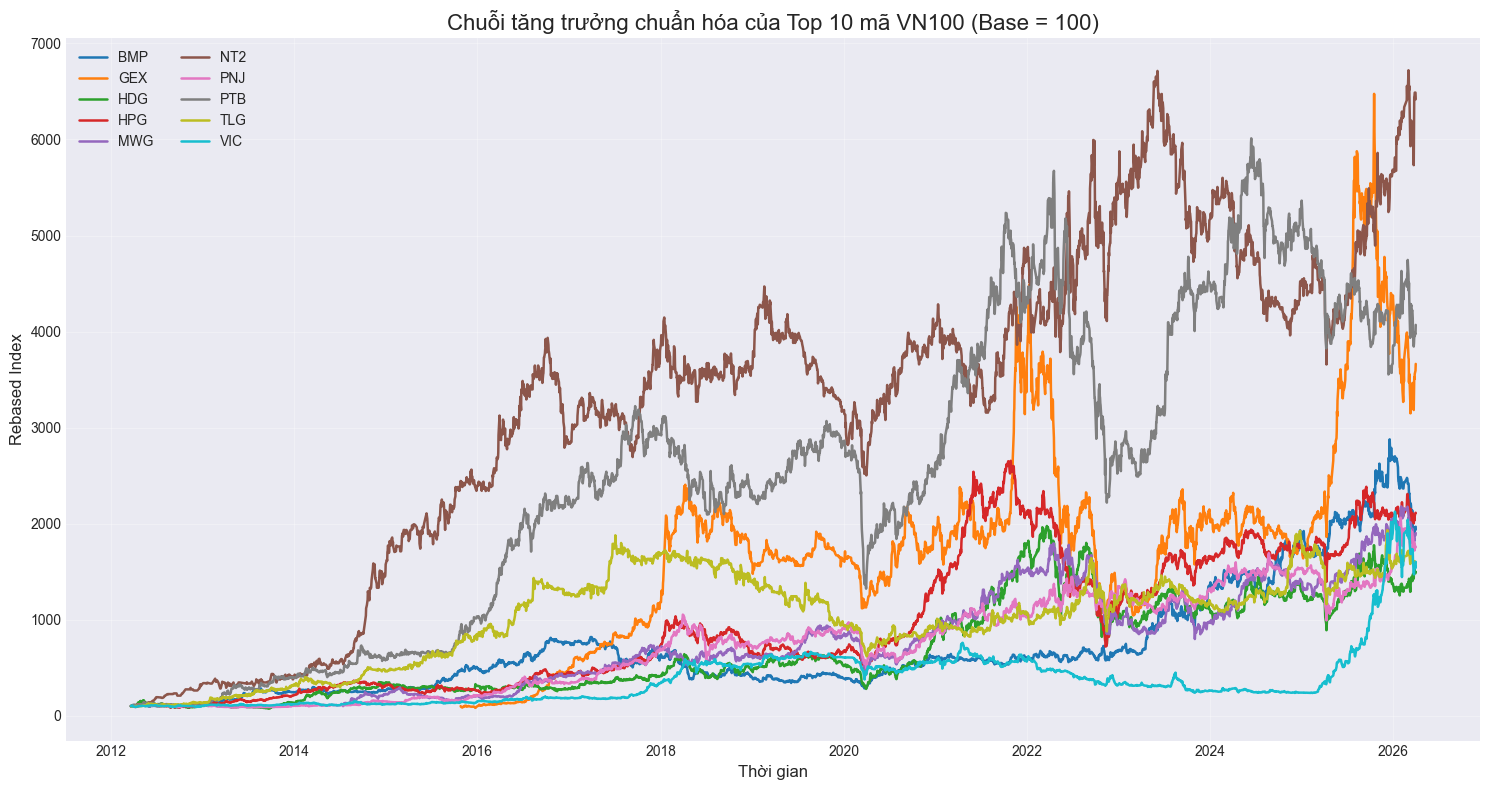

In [36]:

# 5.3 Vẽ growth chuẩn hóa của một số mã tăng trưởng tốt nhất

top_n = 10
top_tickers = growth_summary.head(top_n)['code'].tolist()

plot_df = growth_df[growth_df['code'].isin(top_tickers)].copy()

plt.figure(figsize=(15, 8))
for ticker, sub_df in plot_df.groupby('code'):
    plt.plot(sub_df['Date'], sub_df['rebased_100'], linewidth=1.8, label=ticker)

plt.title(f'Chuỗi tăng trưởng chuẩn hóa của Top {top_n} mã VN100 (Base = 100)', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Rebased Index', fontsize=12)
plt.legend(ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Growth summary của mã NT2:


,code,start_date,end_date,start_price,end_price,observations,total_growth,total_growth_pct
0,NT2,2012-03-19,2026-03-31,430.0,27600.0,3306,63.186047,6318.604651


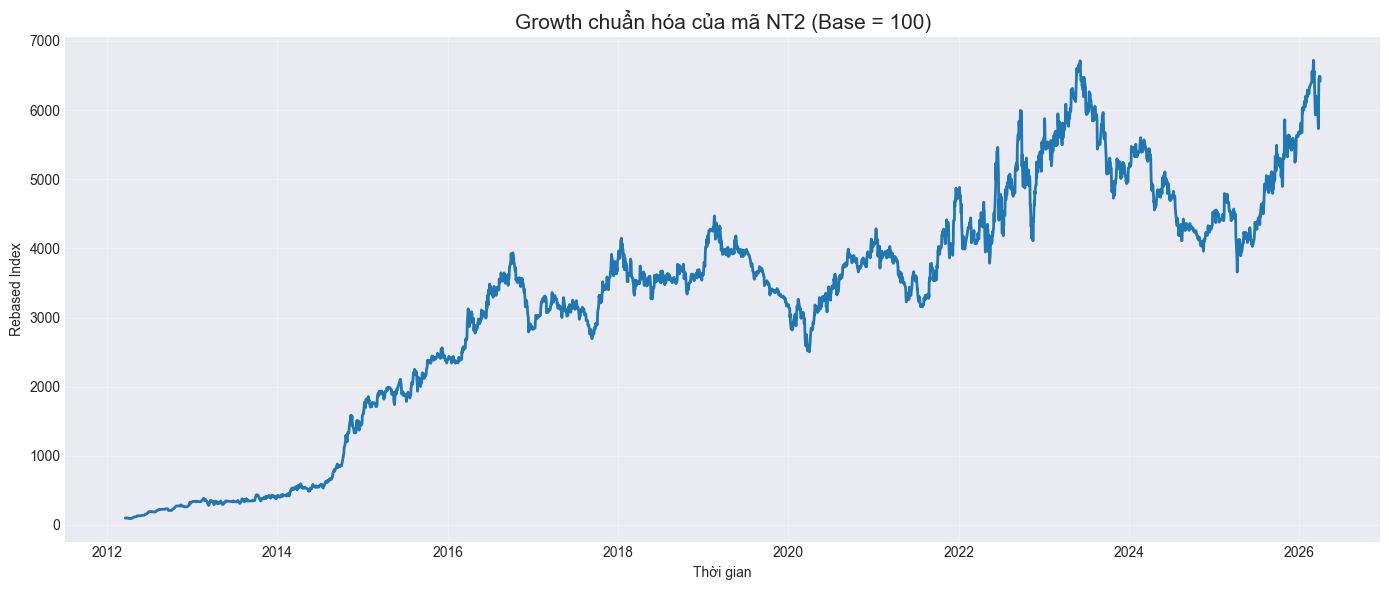

In [37]:

# 5.4 Có thể lấy growth của riêng một mã bất kỳ

ticker_to_check = growth_summary.iloc[0]['code']  # đổi mã tại đây nếu muốn
ticker_growth = growth_df[growth_df['code'] == ticker_to_check].copy()

print(f"Growth summary của mã {ticker_to_check}:")
display(growth_summary[growth_summary['code'] == ticker_to_check])

plt.figure(figsize=(14, 6))
plt.plot(ticker_growth['Date'], ticker_growth['rebased_100'], linewidth=2)
plt.title(f'Growth chuẩn hóa của mã {ticker_to_check} (Base = 100)', fontsize=15)
plt.xlabel('Thời gian')
plt.ylabel('Rebased Index')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [38]:

# # 5.5 Xuất bảng tổng hợp growth ra CSV nếu cần

# output_summary_path = 'vn100_growth_summary.csv'
# output_series_path = 'vn100_growth_series.csv'

# growth_summary.to_csv(output_summary_path, index=False)
# growth_df.to_csv(output_series_path, index=False)

# print(f"Đã lưu summary: {output_summary_path}")
# print(f"Đã lưu chuỗi growth: {output_series_path}")


5 dòng đầu của chuỗi VN100 đã chuẩn hóa về thang 100:


,daily_return,cum_return,vn100_base_100,vn100_growth_pct
Date,,,,
2012-03-19,0.023810,1.023810,102.380952,2.380952
2012-03-20,0.011309,1.035388,103.538818,3.538818
2012-03-21,0.007119,1.042759,104.275892,4.275892
2012-03-22,0.009204,1.052356,105.235613,5.235613
2012-03-23,0.003675,1.056224,105.622375,5.622375


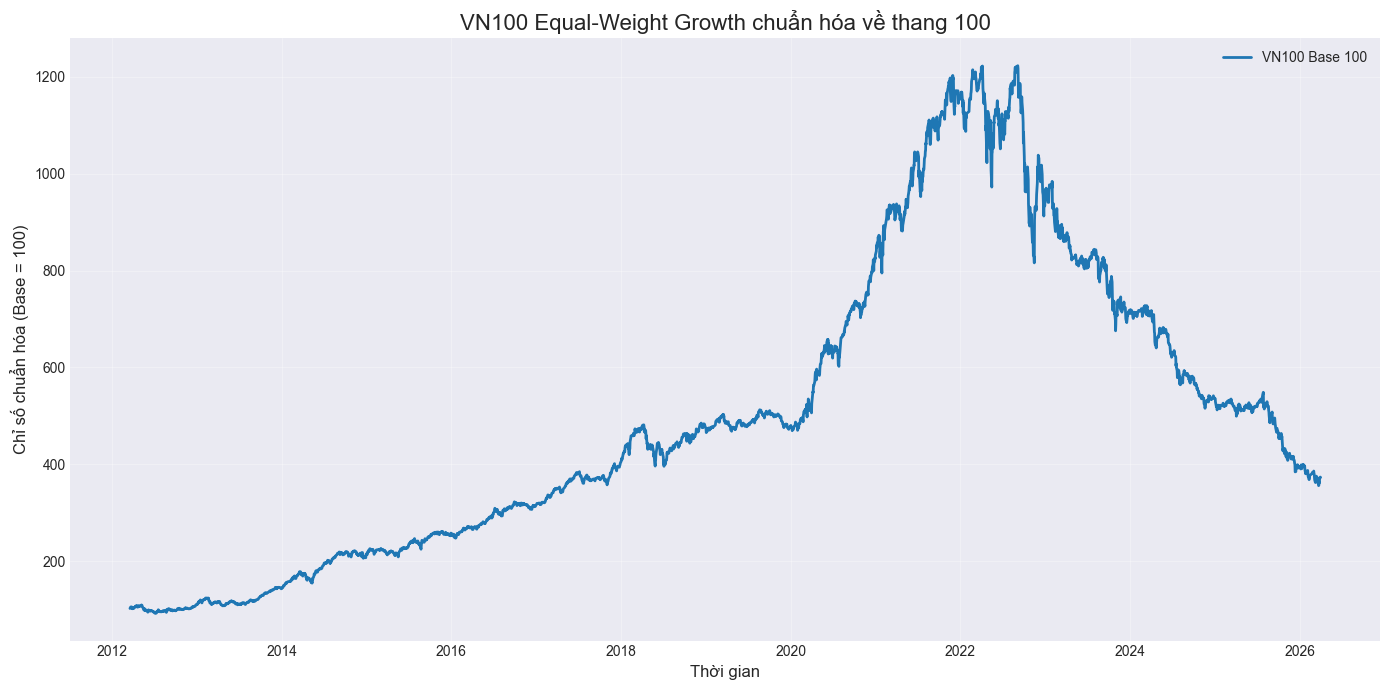

Đã lưu: vn100_index_base100.csv


In [39]:
# 5.6 Chuẩn hóa growth của toàn bộ VN100 về thang 100

vn100_daily = vn100_daily.sort_index().copy()

# Vì cum_return đã bắt đầu từ 1, chỉ cần đổi base từ 1000 về 100
vn100_daily['vn100_base_100'] = 100 * vn100_daily['cum_return']

# Có thể tính thêm growth lũy kế dưới dạng %
vn100_daily['vn100_growth_pct'] = (vn100_daily['cum_return'] - 1) * 100

print("5 dòng đầu của chuỗi VN100 đã chuẩn hóa về thang 100:")
display(vn100_daily[['daily_return', 'cum_return', 'vn100_base_100', 'vn100_growth_pct']].head())

plt.figure(figsize=(14, 7))
plt.plot(vn100_daily.index, vn100_daily['vn100_base_100'], linewidth=2, label='VN100 Base 100')
plt.title('VN100 Equal-Weight Growth chuẩn hóa về thang 100', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Chỉ số chuẩn hóa (Base = 100)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Nếu muốn lưu riêng chuỗi này ra CSV
vn100_daily[['daily_return', 'cum_return', 'vn100_base_100', 'vn100_growth_pct']].to_csv('vn100_index_base100.csv')
print("Đã lưu: vn100_index_base100.csv")